In [3]:
from google.colab import files
uploaded = files.upload()

Saving Titanic-Dataset.csv to Titanic-Dataset.csv


In [4]:
import os
print(os.listdir())

['.config', 'Titanic-Dataset.csv', 'sample_data']


In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("Titanic-Dataset.csv")
df.head()


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [6]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [7]:
df.isnull().sum()


,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,0


In [8]:
# Age: fill with the median
df["Age"] = df["Age"].fillna(df["Age"].median())

# Embarked: fill with the most common value (mode)
df["Embarked"] = df["Embarked"].fillna(df["Embarked"].mode()[0])

# Cabin: drop it, because most of its values are missing
df = df.drop(columns=["Cabin"])

# Drop columns that aren't useful for ML
df = df.drop(columns=["PassengerId", "Name", "Ticket"])


In [9]:
df.isnull().sum()


,0
Survived,0
Pclass,0
Sex,0
Age,0
SibSp,0
Parch,0
Fare,0
Embarked,0


In [10]:
# Sex: label encoding (only two values)
df["Sex"] = df["Sex"].map({"male": 0, "female": 1})

# Embarked: one-hot encoding (three values: C, Q, S)
df = pd.get_dummies(df, columns=["Embarked"], drop_first=True)

df.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked_Q,Embarked_S
0,0,3,0,22.0,1,0,7.2500,False,True
1,1,1,1,38.0,1,0,71.2833,False,False
2,1,3,1,26.0,0,0,7.9250,False,True
3,1,1,1,35.0,1,0,53.1000,False,True
4,0,3,0,35.0,0,0,8.0500,False,True


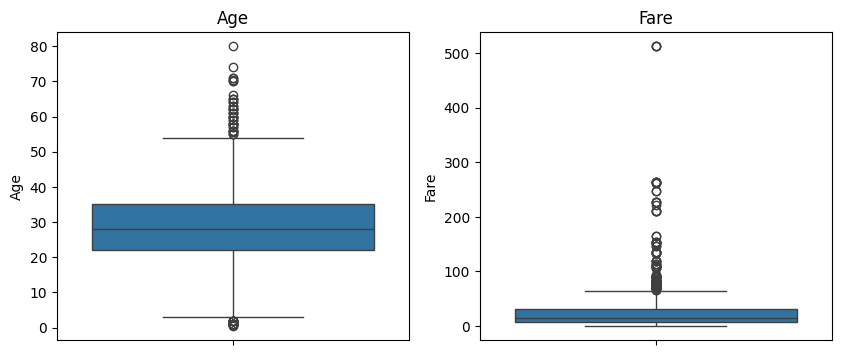

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

sns.boxplot(y=df["Age"], ax=axes[0])
axes[0].set_title("Age")

sns.boxplot(y=df["Fare"], ax=axes[1])
axes[1].set_title("Fare")

plt.savefig("boxplots_before.png")
plt.show()


In [12]:
before = len(df)

for col in ["Age", "Fare"]:
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    df = df[(df[col] >= lower) & (df[col] <= upper)]

after = len(df)
print("Rows before:", before)
print("Rows after:", after)
print("Rows removed:", before - after)

Rows before: 891
Rows after: 718
Rows removed: 173


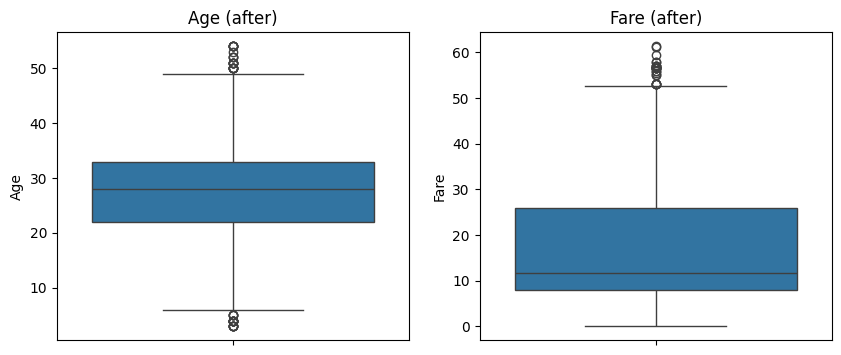

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

sns.boxplot(y=df["Age"], ax=axes[0])
axes[0].set_title("Age (after)")

sns.boxplot(y=df["Fare"], ax=axes[1])
axes[1].set_title("Fare (after)")

plt.savefig("boxplots_after.png")
plt.show()

In [14]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
df[["Age", "Fare"]] = scaler.fit_transform(df[["Age", "Fare"]])

df[["Age", "Fare"]].describe()


,Age,Fare
count,7.180000e+02,7.180000e+02
mean,1.731824e-16,-8.906525e-17
std,1.000697e+00,1.000697e+00
min,-2.506587e+00,-1.299043e+00
25%,-6.076110e-01,-7.029415e-01
50%,-7.934439e-03,-4.112647e-01
75%,4.793028e-01,6.599744e-01
max,2.590664e+00,3.338501e+00


In [15]:
df.to_csv("cleaned_data.csv", index=False)

from google.colab import files
files.download("cleaned_data.csv")
files.download("boxplots_before.png")
files.download("boxplots_after.png")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>